In [20]:
import pandas as pd
from yahooquery import Ticker
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
etfs = ["SPY","QQQ","IWM","EFA","EEM","XLK","XLE","XLV","VNQ","TLT"]
stocks = ["AAPL","MSFT","NVDA","JPM","JNJ","XOM","KO","AMZN","CAT","V"]

In [3]:
etf_data = Ticker(etfs)
stock_data = Ticker(stocks)

etf_hist = etf_data.history(start="2005-01-01", end="2014-12-31", interval="1d")
stock_hist = stock_data.history(start="2005-01-01", end="2014-12-31", interval="1d")

In [9]:
etf_df = (
    etf_hist.reset_index()
        .loc[:, ["date", "symbol", "adjclose"]]
        .dropna(subset=["adjclose"])
)

stock_df = (
    stock_hist.reset_index()
        .loc[:, ["date", "symbol", "adjclose"]]
        .dropna(subset=["adjclose"])
)

In [10]:
etf_df = (etf_df
          .assign(date=pd.to_datetime(etf_df["date"]))
          .pivot(index="date", columns="symbol", values="adjclose")
          .sort_index())
          
stock_df = (stock_df
          .assign(date=pd.to_datetime(stock_df["date"]))
          .pivot(index="date", columns="symbol", values="adjclose")
          .sort_index())

In [11]:
etf_df.head()

symbol,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV
date,,,,,,,,,,
2005-01-03,14.562674,28.951874,48.275021,33.695381,81.605980,44.887241,22.788919,9.636079,8.029552,20.910583
2005-01-04,14.114315,28.396851,47.240170,33.081177,80.608795,44.416798,22.446407,9.586494,7.879929,20.742397
2005-01-05,13.941529,28.378658,46.295979,32.876450,80.052536,44.654568,21.700239,9.545172,7.853072,20.707369
2005-01-06,13.932055,28.378658,46.541481,32.714375,80.459572,44.684898,21.867413,9.710463,7.830056,20.861534
2005-01-07,13.959027,28.251272,46.024055,32.884975,80.344238,44.786091,21.818485,9.633326,7.845401,20.847521


In [14]:
# find returns
etf_ret = etf_df.pct_change().dropna(how="all")
stock_ret = stock_df.pct_change().dropna(how="all")

In [22]:
# --- correlation heatmap ---
etf_corr = etf_ret.corr()
stock_corr = stock_ret.corr()

def plot_corr_heatmap_annot(corr_mat, title, fmt="{:.2f}", fontsize=9):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr_mat.values, aspect="equal", vmin=-1, vmax=1)

    ax.set_title(title, pad=12)

    # ticks & labels
    ax.set_xticks(range(len(corr_mat.columns)))
    ax.set_yticks(range(len(corr_mat.index)))
    ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_mat.index)

    # gridlines
    ax.set_xticks(np.arange(-.5, len(corr_mat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(corr_mat.index), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation", rotation=90)

    # --- annotate each cell with value ---
    vals = corr_mat.values
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=fontsize)

    plt.tight_layout()
    plt.show()


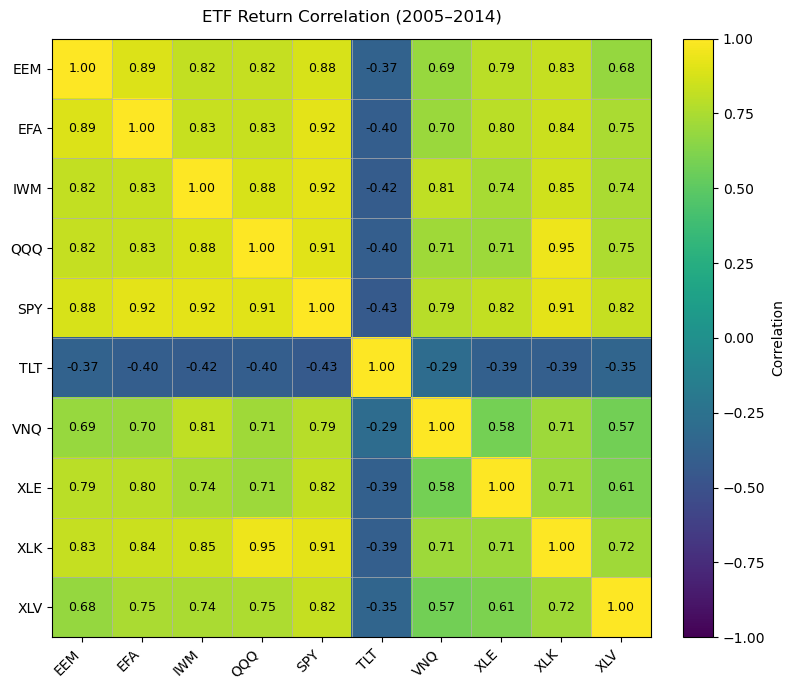

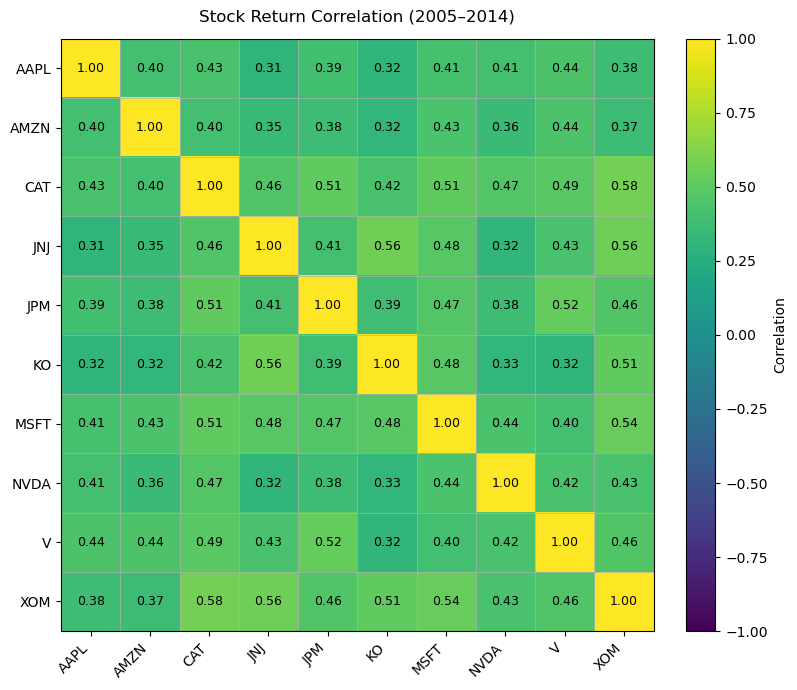

In [23]:
plot_corr_heatmap_annot(etf_corr, "ETF Return Correlation (2005–2014)", fmt="{:.2f}", fontsize=9)
plot_corr_heatmap_annot(stock_corr, "Stock Return Correlation (2005–2014)", fmt="{:.2f}", fontsize=9)